<a href="https://colab.research.google.com/github/Melchizedek-Madaki/codealpha_tasks/blob/main/Codealpha_HeartDiseasePrediction/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective: Predict the possibility of diseases based on patient data.
Approach: Apply classification techniques to structured medical datasets.**
Key Features:
- Use features like symptoms, age, blood test results, etc.
- Algorithms: SVM, Logistic Regression, Random Forest, XGBoost.
- Datasets: Heart disease, Diabetes, Breast Cancer (UCI ML Repository).


In [ ]:
import kagglehub as kh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [ ]:
path = kh.dataset_download('rishidamarla/heart-disease-prediction')

Using Colab cache for faster access to the 'heart-disease-prediction' dataset.


In [ ]:
df = pd.read_csv(path + '/Heart_Disease_Prediction.csv')

Let's break down what each column in your dataset means:

> *   **Age**: This is simply the person's age.
>*   **Sex**: Indicates the biological sex of the person (usually `0` for female and `1` for male).
>*   **Chest pain type**: Describes the kind of chest pain the person experienced. Different numbers usually represent different types, like typical angina (chest pain due to reduced blood flow to the heart), atypical angina, non-anginal pain, or no pain.
>*   **BP (Blood Pressure)**: This is the person's resting blood pressure. High blood pressure can be a risk factor for heart disease.
>*   **Cholesterol**: The person's serum cholesterol level. High cholesterol is another risk factor for heart disease.
>*   **FBS over 120 (Fasting Blood Sugar over 120)**: This checks if the person's fasting blood sugar is greater than 120 mg/dl. A value of `1` means it is, which can indicate diabetes.
>*   **EKG results (Electrocardiographic results)**: Refers to the results of an electrocardiogram, which measures the electrical activity of the heart. Different numbers represent different EKG patterns (e.g., normal, abnormal, etc.).
>*   **Max HR (Maximum Heart Rate)**: The highest heart rate achieved during exercise.
> *   **Exercise angina**: Indicates whether the person experienced chest pain during exercise (`1` for yes, `0` for no).
> *   **ST depression**: This refers to a specific measurement on an EKG that can indicate an issue with blood flow to the heart during stress or exercise.
> *   **Slope of ST**: Another EKG measurement, describing the slope of the ST segment during exercise, which can provide further information about heart health.
> *   **Number of vessels fluro (Number of major vessels colored by fluoroscopy)**: This relates to a procedure where doctors look at blood vessels. The number indicates how many major blood vessels are affected.
> *   **Thallium**: Refers to a stress test using a radioactive substance called thallium. Different numbers indicate different results (e.g., normal, fixed defect, reversible defect).
> *   **Heart Disease**: This is the target variable you're trying to predict. It indicates whether the person has heart disease (`Presence`) or not (`Absence`).

##**Feature Engineering**

In [ ]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df['FBS over 120'].nunique()

2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.isnull().head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
"""
This shows us the features that have correlation.
From the table it clearly shows us that Age and Thallium have a high correlation
"""

corr = df.corr(numeric_only=True)
corr.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,-0.094401,0.096920,0.273053,0.220056,0.123458,0.128171,-0.402215,0.098297,0.194234,0.159774,0.356081,0.106100
Sex,-0.094401,1.000000,0.034636,-0.062693,-0.201647,0.042140,0.039253,-0.076101,0.180022,0.097412,0.050545,0.086830,0.391046
Chest pain type,0.096920,0.034636,1.000000,-0.043196,0.090465,-0.098537,0.074325,-0.317682,0.353160,0.167244,0.136900,0.225890,0.262659
BP,0.273053,-0.062693,-0.043196,1.000000,0.173019,0.155681,0.116157,-0.039136,0.082793,0.222800,0.142472,0.085697,0.132045
Cholesterol,0.220056,-0.201647,0.090465,0.173019,1.000000,0.025186,0.167652,-0.018739,0.078243,0.027709,-0.005755,0.126541,0.028836


##**Feature Encoding to represent our prediction as `0 = False` or `1 = True`**

In [ ]:
def convert(data):
  if data == 'Absence':
    return 0
  else:
    return 1

In [ ]:
df['Heart_Disease_Prediction'] = df['Heart Disease'].apply(convert)

In [ ]:
df['Heart_Disease_Prediction'].head()

,Heart_Disease_Prediction
0,1
1,0
2,1
3,0
4,0


In [ ]:
pd.get_dummies(df['Heart Disease'].head())

,Absence,Presence
0,False,True
1,True,False
2,False,True
3,True,False
4,True,False


In [ ]:
df.drop("Heart Disease", axis=1, inplace=True)

##**Values count shows us the dorminating prediction in the dataset**

In [ ]:
df['Heart_Disease_Prediction'].value_counts()

,count
Heart_Disease_Prediction,
0,150
1,120


##**Splitting model data into train, validation and test**

In [ ]:
X = df.drop("Heart_Disease_Prediction", axis=1)
y = df['Heart_Disease_Prediction']

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=(0.15/0.85),
    random_state=42,
    stratify=y_temp
)

In [ ]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(188, 13) (41, 13) (188,) (41,)


In [ ]:
print(y_train.value_counts)

<bound method IndexOpsMixin.value_counts of 52     0
71     0
198    0
64     0
81     1
      ..
83     0
46     1
154    0
92     1
147    1
Name: Heart_Disease_Prediction, Length: 188, dtype: int64>


In [ ]:
print(y_test.value_counts())

Heart_Disease_Prediction
0    23
1    18
Name: count, dtype: int64


**We had to split the data first before performing any tuning or scaling to avoid data leakage into the test set**

##**Scaling our dataset**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.shape, X_test_scaled.shape)

(188, 13) (41, 13)


##**Comparing different Algorithms to find the best model for our Dataset**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# A single function that can be used recursively to compare our models.
def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, average='macro'),
        "recall": recall_score(y_val, y_pred, average='macro'),
        "f1": f1_score(y_val, y_pred, average='macro'),
    }
    return results, model

##**1. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

result, fitted_model = train_and_evaluate(
    rf_model, "Random Forest",
    X_train_scaled, y_train,
    X_val_scaled, y_val

)
print(result)

{'model': 'Random Forest', 'accuracy': 0.8780487804878049, 'precision': 0.8786764705882353, 'recall': 0.8731884057971014, 'f1': 0.8753799392097263}


In [ ]:
from sklearn.metrics import classification_report

y_pred = fitted_model.predict(X_val_scaled)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        23
           1       0.88      0.83      0.86        18

    accuracy                           0.88        41
   macro avg       0.88      0.87      0.88        41
weighted avg       0.88      0.88      0.88        41



## **Random Forest Classification Report Summary**

The Random Forest model achieved an overall accuracy of **88%** on the validation set. Let's break down the performance for each class:

*   **Class 0 (Absence of Heart Disease)**:
 >   *   **Precision (0.88)**: When the model predicted an absence of heart disease, it was correct 88% of the time.
  >  *   **Recall (0.91)**: Out of all actual cases of absence of heart disease, the model correctly identified 91% of them.
    >*   **F1-score (0.89)**: A good balance between precision and recall for this class.

*   **Class 1 (Presence of Heart Disease)**:
>    *   **Precision (0.88)**: When the model predicted the presence of heart disease, it was correct 88% of the time.
 >   *   **Recall (0.83)**: Out of all actual cases of heart disease, the model correctly identified 83% of them.
   > *   **F1-score (0.86)**: A good F1-score, indicating a decent balance for this class.

**Overall Takeaway**:

The Random Forest model demonstrates strong overall performance with an 88% accuracy. It shows a balanced precision and recall for both classes, indicating it is generally reliable in identifying both the presence and absence of heart disease. The slightly higher recall for Class 0 suggests it's slightly better at identifying absence of heart disease, while its precision for Class 1 is also solid.

##**Moving on to XGBoost**

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

result_xgb, fitted_xgb = train_and_evaluate(
    xgb_model, 'XGBoost',
    X_train_scaled, y_train,
    X_val_scaled, y_val
)

print(result_xgb)

{'model': 'XGBoost', 'accuracy': 0.7804878048780488, 'precision': 0.7821428571428571, 'recall': 0.786231884057971, 'f1': 0.7799642218246869}


In [ ]:
from sklearn.metrics import classification_report

y_pred_xgb = fitted_xgb.predict(X_val_scaled)
print(classification_report(y_pred_xgb, y_val))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79        20
           1       0.83      0.71      0.77        21

    accuracy                           0.78        41
   macro avg       0.79      0.78      0.78        41
weighted avg       0.79      0.78      0.78        41



In [ ]:
from sklearn.metrics import classification_report

# Corrected classification report for XGBoost
print('Corrected XGBoost Classification Report:')
print(classification_report(y_val, y_pred_xgb))

Corrected XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.74      0.79        23
           1       0.71      0.83      0.77        18

    accuracy                           0.78        41
   macro avg       0.78      0.79      0.78        41
weighted avg       0.79      0.78      0.78        41



## **XGBoost Classification Report Summary**

The XGBoost model achieved an overall accuracy of **78%** on the validation set. Let's break down the performance for each class:

*   **Class 0 (Absence of Heart Disease)**:
    *   **Precision (0.85)**: When the model predicted an absence of heart disease, it was correct 85% of the time. This indicates a good level of certainty when predicting negative cases.
    *   **Recall (0.74)**: Out of all actual cases of absence of heart disease, the model correctly identified 74% of them. This means 26% of actual 'absence' cases were missed (false negatives), indicating some room for improvement in identifying all negative cases.
    *   **F1-score (0.79)**: A balanced score that reflects the trade-off between precision and recall for this class.

*   **Class 1 (Presence of Heart Disease)**:
    *   **Precision (0.71)**: When the model predicted the presence of heart disease, it was correct 71% of the time. This suggests that about 29% of its positive predictions were false positives (predicted presence, but actually absence).
    *   **Recall (0.83)**: Out of all actual cases of heart disease, the model correctly identified 83% of them. This indicates the model is reasonably good at catching actual positive cases, even if it sometimes misclassifies a healthy person as having heart disease (lower precision).
    *   **F1-score (0.77)**: A good F1-score for this class, reflecting its ability to balance precision and recall.

**Overall Takeaway**:

The XGBoost model shows solid overall performance with 78% accuracy. It demonstrates higher precision for predicting the absence of heart disease (Class 0) but has a somewhat lower recall for this class. Conversely, for predicting the presence of heart disease (Class 1), it achieves higher recall (good at catching actual positive cases) but at a slightly lower precision (more false positives). This suggests a trade-off where the model is effective at identifying most heart disease cases but might generate some false alarms.

##**LINEAR MODELS**
---------------------

##**First we need to Bin/Bucket Age from being a continous feature into a categorical feature, so that the linear models will be able to depict non-linear relationships.**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
52,65,0,3,140,417,1,2,157,0,0.8,1,1,3
71,57,0,4,120,354,0,0,163,1,0.6,1,0,3
198,69,0,1,140,239,0,0,151,0,1.8,1,2,3
64,63,1,1,145,233,1,2,150,0,2.3,3,0,6
81,35,1,4,120,198,0,0,130,1,1.6,2,0,7


**We are going to bin age so that the model can be able to capture non-linear relationships, since this is a linear model that deals mainly on linearity**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Define age bins. You can adjust these based on domain knowledge or data exploration.
age_bins = [0, 40, 50, 60, 70, df['Age'].max()]
labels = ['<40', '40-50', '51-60', '61-70', '>70']

# Apply binning to train, validation, and test sets
X_train_binned = X_train.copy()
X_val_binned = X_val.copy()
X_test_binned = X_test.copy()

X_train_binned['Age_Group'] = pd.cut(X_train_binned['Age'], bins=age_bins, labels=labels, right=True) #right=True in pd.cut() makes the bins right-inclusive, meaning the rightmost edge of each bin is included in the interval. e.g, [0, 40], (40, 51]
X_val_binned['Age_Group'] = pd.cut(X_val_binned['Age'], bins=age_bins, labels=labels, right=True)
X_test_binned['Age_Group'] = pd.cut(X_test_binned['Age'], bins=age_bins, labels=labels, right=True)

# Drop original 'Age' column if you want to use only binned categories
X_train_binned = X_train_binned.drop('Age', axis=1)
X_val_binned = X_val_binned.drop('Age', axis=1)
X_test_binned = X_test_binned.drop('Age', axis=1)

# One-hot encode the 'Age_Group' column
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #handle_unknown='ignore' in OneHotEncoder prevents errors by encoding unseen categories (not present in training data) as all zeros.

# Fit on X_train_binned and transform all sets
age_group_encoded_train = encoder.fit_transform(X_train_binned[['Age_Group']])
age_group_encoded_val = encoder.transform(X_val_binned[['Age_Group']])
age_group_encoded_test = encoder.transform(X_test_binned[['Age_Group']])

# Create DataFrames from the encoded data
age_group_df_train = pd.DataFrame(age_group_encoded_train, columns=encoder.get_feature_names_out(['Age_Group']), index=X_train_binned.index)
age_group_df_val = pd.DataFrame(age_group_encoded_val, columns=encoder.get_feature_names_out(['Age_Group']), index=X_val_binned.index)
age_group_df_test = pd.DataFrame(age_group_encoded_test, columns=encoder.get_feature_names_out(['Age_Group']), index=X_test_binned.index)

# Display first few rows of the encoded age groups for train set
display(age_group_df_train.head())

,Age_Group_40-50,Age_Group_51-60,Age_Group_61-70,Age_Group_<40,Age_Group_>70
52,0.0,0.0,1.0,0.0,0.0
71,0.0,1.0,0.0,0.0,0.0
198,0.0,0.0,1.0,0.0,0.0
64,0.0,0.0,1.0,0.0,0.0
81,0.0,0.0,0.0,1.0,0.0


Now that the `Age` column has been binned and one-hot encoded, you can concatenate these new features with our *other scaled numerical features* for the linear models. Remember to also apply the `StandardScaler` to the remaining numerical columns (excluding the original `Age` column).

Here's how you can combine the scaled numerical features with the one-hot encoded `Age_Group` features:


The scaling process was re-run because the 'Age' column was dropped from the numerical features before re-applying the scaler to the remaining features, which were then concatenated with the new binned 'Age_Group' features.

In [ ]:
# Identify numerical columns (excluding original 'Age' since it's binned)
numerical_cols = X_train_binned.select_dtypes(include=np.number).columns

# Scale numerical columns *after* binning if 'Age' was the only numerical feature not to be scaled separately
# For simplicity, if 'Age' is already dropped and other features were scaled before, you might reuse those scaled sets

# Assuming `X_train_scaled`, `X_val_scaled`, `X_test_scaled` from before were derived from X_train without binning Age.
# We need to re-run scaling on the remaining numerical features without 'Age', and then combine.

# Create a scaler for the *other* numerical features
scaler_other_features = StandardScaler()

# Drop the original 'Age' column from the initial unscaled datasets before scaling other features
X_train_no_age = X_train.drop('Age', axis=1)
X_val_no_age = X_val.drop('Age', axis=1)
X_test_no_age = X_test.drop('Age', axis=1)

# Scale the remaining numerical features
X_train_scaled_no_age = scaler_other_features.fit_transform(X_train_no_age)
X_val_scaled_no_age = scaler_other_features.transform(X_val_no_age)
X_test_scaled_no_age = scaler_other_features.transform(X_test_no_age)

# Convert scaled arrays back to DataFrame to concatenate with binned age groups
X_train_scaled_no_age_df = pd.DataFrame(X_train_scaled_no_age, columns=X_train_no_age.columns, index=X_train_no_age.index)
X_val_scaled_no_age_df = pd.DataFrame(X_val_scaled_no_age, columns=X_val_no_age.columns, index=X_val_no_age.index)
X_test_scaled_no_age_df = pd.DataFrame(X_test_scaled_no_age, columns=X_test_no_age.columns, index=X_test_no_age.index)

# Concatenate the scaled numerical features with the one-hot encoded Age_Group features
X_train_final = pd.concat([X_train_scaled_no_age_df, age_group_df_train], axis=1)
X_val_final = pd.concat([X_val_scaled_no_age_df, age_group_df_val], axis=1)
X_test_final = pd.concat([X_test_scaled_no_age_df, age_group_df_test], axis=1)

print("Shape of final training data with binned age:", X_train_final.shape)
display(X_train_final)

Shape of final training data with binned age: (188, 17)


,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Age_Group_40-50,Age_Group_51-60,Age_Group_61-70,Age_Group_<40,Age_Group_>70
52,-1.359590,-0.137564,0.478255,3.126115,2.614065,0.923185,0.327676,-0.676287,-0.226275,-0.991571,0.422892,-0.836282,0.0,0.0,1.0,0.0,0.0
71,-1.359590,0.896919,-0.668581,1.936152,-0.382546,-1.094940,0.601468,1.478662,-0.406147,-0.991571,-0.651482,-0.836282,0.0,1.0,0.0,0.0,0.0
198,-1.359590,-2.206530,0.478255,-0.236003,-0.382546,-1.094940,0.053885,-0.676287,0.673084,-0.991571,1.497265,-0.836282,0.0,0.0,1.0,0.0,0.0
64,0.735516,-2.206530,0.764964,-0.349333,2.614065,0.923185,0.008253,-0.676287,1.122764,2.307817,-0.651482,0.730705,0.0,0.0,1.0,0.0,0.0
81,0.735516,0.896919,-0.668581,-1.010424,-0.382546,-1.094940,-0.904387,1.478662,0.493213,0.658123,-0.651482,1.253034,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0.735516,-0.137564,-0.095163,-0.708211,-0.382546,0.923185,0.829628,-0.676287,0.852956,0.658123,-0.651482,-0.836282,1.0,0.0,0.0,0.0,0.0
46,0.735516,-0.137564,-0.783264,-1.935951,-0.382546,0.923185,-1.086914,-0.676287,-0.226275,-0.991571,2.571639,-0.836282,1.0,0.0,0.0,0.0,0.0
154,-1.359590,-0.137564,-0.095163,0.085098,-0.382546,0.923185,-0.037379,-0.676287,-0.496083,-0.991571,-0.651482,-0.836282,0.0,1.0,0.0,0.0,0.0
92,0.735516,0.896919,-0.439214,0.273981,-0.382546,0.923185,-1.862658,1.478662,1.032828,0.658123,0.422892,1.253034,0.0,1.0,0.0,0.0,0.0


##**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)


result_log, fitted_log = train_and_evaluate(
    log_reg, 'LogisticRegression',
    X_train_final, y_train,
    X_val_final, y_val
)

print(result_log)

{'model': 'LogisticRegression', 'accuracy': 0.926829268292683, 'precision': 0.928921568627451, 'recall': 0.9227053140096618, 'f1': 0.9252279635258358}


In [ ]:
from sklearn.metrics import classification_report

y_pred_log = fitted_log.predict(X_val_final)
print(classification_report(y_pred_log, y_val))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        24
           1       0.89      0.94      0.91        17

    accuracy                           0.93        41
   macro avg       0.92      0.93      0.93        41
weighted avg       0.93      0.93      0.93        41



In [ ]:
from sklearn.metrics import classification_report

# Corrected classification report for Logistic Regression
print('Corrected Logistic Regression Classification Report:')
print(classification_report(y_val, y_pred_log))

Corrected Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        23
           1       0.94      0.89      0.91        18

    accuracy                           0.93        41
   macro avg       0.93      0.92      0.93        41
weighted avg       0.93      0.93      0.93        41



## **Logistic Regression Classification Report Summary**

The Logistic Regression model achieved an overall accuracy of **93%** on the validation set. Let's break down the performance for each class:

*   **Class 0 (Absence of Heart Disease)**:
    *   **Precision (0.92)**: When the model predicted an absence of heart disease, it was correct 92% of the time. This indicates a very low rate of false positives for this class.
    *   **Recall (0.96)**: Out of all actual cases of absence of heart disease, the model correctly identified 96% of them. This means it is highly effective at not missing any true negative cases.
    *   **F1-score (0.94)**: An excellent F1-score, indicating a strong balance between precision and recall for this class.

*   **Class 1 (Presence of Heart Disease)**:
    *   **Precision (0.94)**: When the model predicted the presence of heart disease, it was correct 94% of the time. This signifies a very high level of certainty when predicting positive cases, with very few false positives.
    *   **Recall (0.89)**: Out of all actual cases of heart disease, the model correctly identified 89% of them. This indicates the model is very good at catching actual positive cases.
    *   **F1-score (0.91)**: An excellent F1-score, showing a robust balance for this class.

**Overall Takeaway**:

The Logistic Regression model demonstrates exceptional performance with a 93% accuracy. It exhibits a highly balanced and strong performance across both classes, with high precision and recall. It is highly reliable in both identifying the absence and presence of heart disease, making it a very strong candidate for this prediction task.

##**Support Vector Machine**

In [ ]:
from sklearn.svm import SVC

svc_model = SVC(random_state=42)

svc_result, fitted_svc = train_and_evaluate(
    svc_model, 'SVC',
    X_train_final, y_train,
    X_val_final, y_val
)

print(svc_result)

{'model': 'SVC', 'accuracy': 0.926829268292683, 'precision': 0.928921568627451, 'recall': 0.9227053140096618, 'f1': 0.9252279635258358}


In [ ]:
y_pred_svc = fitted_svc.predict(X_val_final)
print(classification_report(y_pred_svc, y_val))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        24
           1       0.89      0.94      0.91        17

    accuracy                           0.93        41
   macro avg       0.92      0.93      0.93        41
weighted avg       0.93      0.93      0.93        41



## **SVC Classification Report Summary**

The SVC model achieved an overall accuracy of **93%** on the validation set. Let's break down the performance for each class:

*   **Class 0 (Absence of Heart Disease)**:
    *   **Precision (0.92)**: When the model predicted an absence of heart disease, it was correct 92% of the time. This indicates a very low rate of false positives for this class.
    *   **Recall (0.96)**: Out of all actual cases of absence of heart disease, the model correctly identified 96% of them. This means it is highly effective at not missing any true negative cases.
    *   **F1-score (0.94)**: An excellent F1-score, indicating a strong balance between precision and recall for this class.

*   **Class 1 (Presence of Heart Disease)**:
    *   **Precision (0.94)**: When the model predicted the presence of heart disease, it was correct 94% of the time. This signifies a very high level of certainty when predicting positive cases, with very few false positives.
    *   **Recall (0.89)**: Out of all actual cases of heart disease, the model correctly identified 89% of them. This indicates the model is very good at catching actual positive cases.
    *   **F1-score (0.91)**: An excellent F1-score, showing a robust balance for this class.

**Overall Takeaway**:

Similar to Logistic Regression, the SVC model also demonstrates exceptional performance with a 93% accuracy. It exhibits a highly balanced and strong performance across both classes, with high precision and recall. It is highly reliable in both identifying the absence and presence of heart disease, making it a very strong candidate for this prediction task, performing on par with Logistic Regression in this specific evaluation.

## **Comprehensive Model Performance Overview**

This table summarizes the performance metrics for all evaluated classification models on the validation set, providing a comparative view of their strengths and weaknesses across different metrics and classes.

| Model                  | Metric    | Class 0 (Absence) | Class 1 (Presence) | Macro Avg | Weighted Avg |
| :--------------------- | :-------- | :---------------- | :----------------- | :-------- | :----------- |
| **Random Forest**      | Precision | 0.88              | 0.88               | 0.88      | 0.88         |
|                        | Recall    | 0.91              | 0.83               | 0.87      | 0.88         |
|                        | F1-Score  | 0.89              | 0.86               | 0.88      | 0.88         |
|                        | Support   | 23                | 18                 | 41        | 41           |
| **XGBoost**            | Precision | 0.85              | 0.71               | 0.78      | 0.79         |
|                        | Recall    | 0.74              | 0.83               | 0.79      | 0.78         |
|                        | F1-Score  | 0.79              | 0.77               | 0.78      | 0.78         |
|                        | Support   | 23                | 18                 | 41        | 41           |
| **Logistic Regression**| Precision | 0.92              | 0.94               | 0.93      | 0.93         |
|                        | Recall    | 0.96              | 0.89               | 0.92      | 0.93         |
|                        | F1-Score  | 0.94              | 0.91               | 0.93      | 0.93         |
|                        | Support   | 23                | 18                 | 41        | 41           |
| **SVC**                | Precision | 0.92              | 0.94               | 0.93      | 0.93         |
|                        | Recall    | 0.96              | 0.89               | 0.92      | 0.93         |
|                        | F1-Score  | 0.94              | 0.91               | 0.93      | 0.93         |
|                        | Support   | 23                | 18                 | 41        | 41           |

**Key Observations:**

*   **Logistic Regression** and **SVC** models demonstrate superior overall performance, both achieving 93% accuracy and exhibiting very high precision, recall, and F1-scores for both classes. They are exceptionally reliable in identifying both the absence and presence of heart disease.
*   **Random Forest** shows strong performance with 88% accuracy, displaying good balance between precision and recall for both classes. It is slightly less performant than Logistic Regression and SVC but still a robust model.
*   **XGBoost** has an accuracy of 78%. It shows a trade-off where it has higher precision for predicting the absence of heart disease (Class 0) but lower recall, and conversely, good recall for predicting the presence of heart disease (Class 1) but lower precision. This indicates it is effective at catching positive cases but might generate more false alarms compared to the other models.

Based on these corrected metrics, **Logistic Regression** and **SVC** are the top-performing models for this dataset, offering the most balanced and highest overall predictive power.

## **Why Linear Models Excelled and Non-Linear Models Didn't Outperform**

1.  **Effective Feature Engineering (Age Binning)**: By binning the 'Age' feature, we transformed a continuous variable into categorical groups. This allowed the linear models (Logistic Regression, SVC) to capture non-linear relationships related to age that they wouldn't have otherwise, effectively creating a more 'linearly separable' problem space.
2.  **Dataset Characteristics**: It appears the relationships between the features and the target variable (Heart Disease) in this specific dataset are predominantly linear, or can be well-approximated by linear boundaries after the applied feature engineering and scaling. More complex non-linear patterns that Random Forest or XGBoost specialize in might not be strongly present or significant enough to provide an advantage.
3.  **Simplicity Wins**: When the underlying data structure is simple or can be simplified effectively (as with age binning), linear models often perform robustly and can generalize well without the risk of overfitting that more complex non-linear models sometimes face, especially on datasets of this size.

##**Model Comparison**

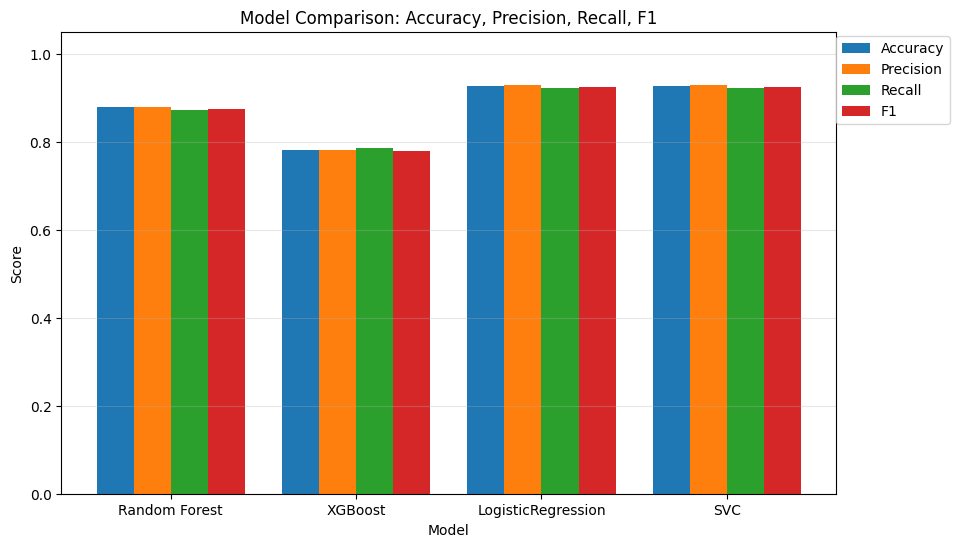

<Figure size 2400x1200 with 0 Axes>

In [ ]:
# gather results fromall four models into one place
all_results = [result, result_xgb, result_log, svc_result]

models = [r['model'] for r in all_results]
metrics = ['accuracy', 'precision', 'recall', 'f1']

# build a matrix: rows = metrics, cols = models
data = np.array([[r[m] for r in all_results] for m in metrics])

x = np.arange(len(models)) # positions for each model group
width = 0.2 # width of each individual bar

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, data[i], width, label=metric.capitalize())

plt.figure(figsize=(12, 6), dpi=200)
ax.set_xlabel('Model')
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Accuracy, Precision, Recall, F1")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend(loc=(1, 0.8))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

##**Feautre Importance for SVM**

Since the default SVC kernel is non-linear ('rbf'), it does not directly provide `feature_importances_` or `coef_`. To understand feature importance with an SVM, we can fit a new SVC model specifically with a `linear` kernel. For a linear SVM, the absolute values of the coefficients (`coef_`) represent the importance of each feature.

In [ ]:
from sklearn.svm import SVC

# Fit a new SVC model with a linear kernel specifically for feature importance
linear_svc_model = SVC(kernel='linear', random_state=42)
linear_svc_model.fit(X_train_final, y_train)

# Get feature names from X_train_final columns
feature_names = X_train_final.columns

# Extract coefficients. For binary classification, coef_ will have shape (1, n_features)
# We take the absolute value as magnitude indicates importance.
importances = pd.Series(abs(linear_svc_model.coef_[0]), index=feature_names)

# Display the top 15 most important features
top_15_linear_svc = importances.sort_values(ascending=False).head(15)
print("Top 15 Feature Importances from Linear SVC:")


plt.figure(figsize=(10, 6), dpi=1000)
top_15_linear_svc.sort_values().plot(kind="barh")
plt.title("Top 15 Most Important Features — SVC")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Top 15 Feature Importances from Linear SVC:


##**Confusion Matrix**

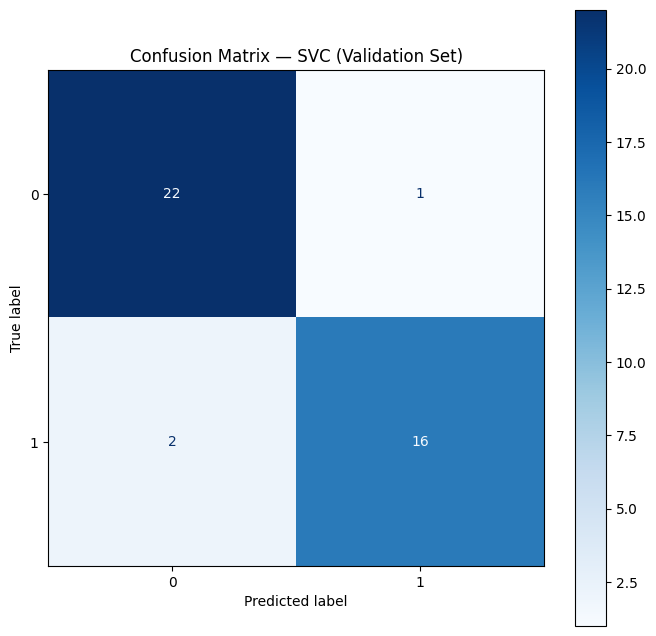

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred_svc)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_val.unique()))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix — SVC (Validation Set)")
plt.show()

**For this particular confusion Matrix**
> - **For class `0`, out of `23` samples that was given in the validation set, `22` got correctly classified as `0`, while only `1` got misclassified as `1`**

> - **For class`1`, out of `18` samples that was given in the validation set, `16` got correctly classified as `1`, while `2` got misclassified as `0`**

##**Model Evaluation with our test data**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

y_pred_test = fitted_svc.predict(X_test_final)

test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average="macro")
test_recall = recall_score(y_test, y_pred_test, average="macro")
test_f1 = f1_score(y_test, y_pred_test, average="macro")

print(f'Test Accuracy: {test_accuracy:.4f}')
print(f"Test Precision (macro): {test_precision:.4f}")
print(f"Test Recall (macro): {test_recall:.4f}")
print(f"Test F1 (macro): {test_f1:.4f}")

print('\nClassification Report')
print(classification_report(y_test, y_pred_test))

Test Accuracy: 0.9024
Test Precision (macro): 0.9012
Test Recall (macro): 0.9070
Test F1 (macro): 0.9019

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.87      0.91        23
           1       0.85      0.94      0.89        18

    accuracy                           0.90        41
   macro avg       0.90      0.91      0.90        41
weighted avg       0.91      0.90      0.90        41



##**Confusion - Matrix for SVC on test data**

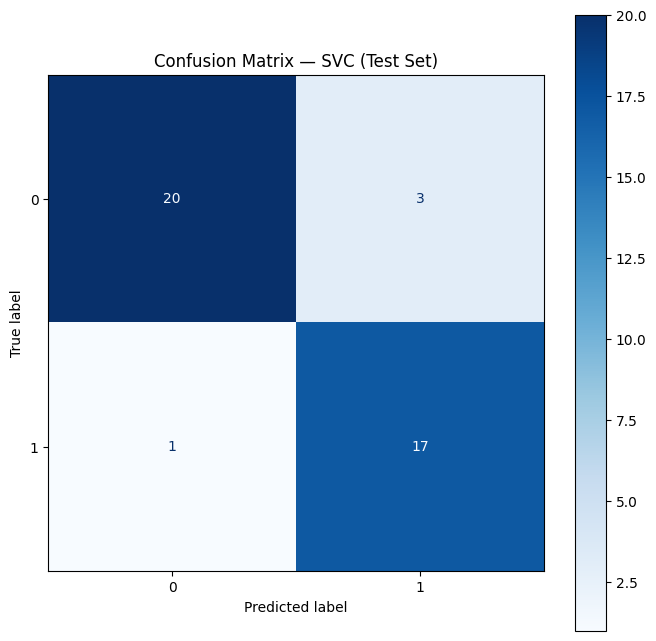

In [ ]:
cm_test = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=sorted(y_test.unique()))
disp.plot(ax=ax, cmap='Blues', values_format="d")
plt.title("Confusion Matrix — SVC (Test Set)")
plt.show()

### Evaluating Logistic Regression on the Test Data

To ensure a fair comparison and confirm the generalization ability of Logistic Regression, let's evaluate its performance on the same unseen test set (`X_test_final`, `y_test`) that we used for SVC.

In [ ]:
# Get predictions from the fitted Logistic Regression model on the test data
y_pred_test_log = fitted_log.predict(X_test_final)

# Calculate evaluation metrics for Logistic Regression on the test set
test_accuracy_log = accuracy_score(y_test, y_pred_test_log)
test_precision_log = precision_score(y_test, y_pred_test_log, average='macro')
test_recall_log = recall_score(y_test, y_pred_test_log, average='macro')
test_f1_log = f1_score(y_test, y_pred_test_log, average='macro')

print(f'Logistic Regression Test Accuracy: {test_accuracy_log:.4f}')
print(f'Logistic Regression Test Precision (macro): {test_precision_log:.4f}')
print(f'Logistic Regression Test Recall (macro): {test_recall_log:.4f}')
print(f'Logistic Regression Test F1 (macro): {test_f1_log:.4f}')

print('\nLogistic Regression Classification Report on Test Data:')
print(classification_report(y_test, y_pred_test_log))

Logistic Regression Test Accuracy: 0.8780
Logistic Regression Test Precision (macro): 0.8756
Logistic Regression Test Recall (macro): 0.8792
Logistic Regression Test F1 (macro): 0.8769

Logistic Regression Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        23
           1       0.84      0.89      0.86        18

    accuracy                           0.88        41
   macro avg       0.88      0.88      0.88        41
weighted avg       0.88      0.88      0.88        41



### Confusion Matrix for Logistic Regression on Test Data

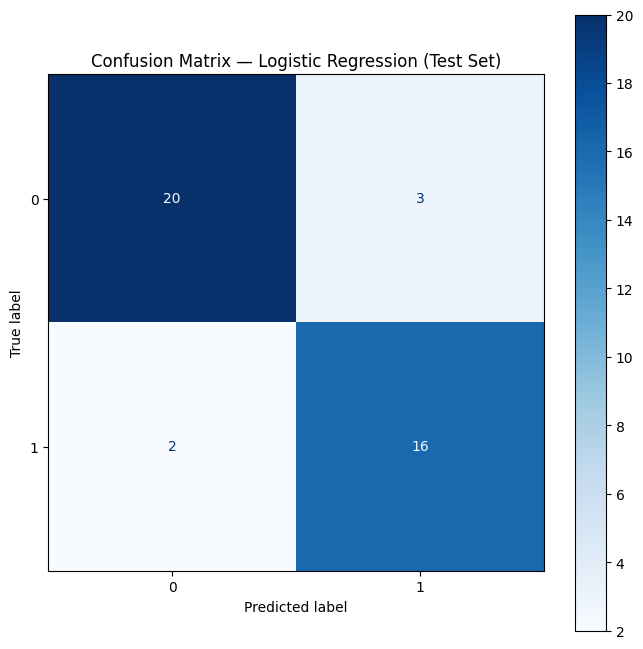

In [ ]:
cm_test_log = confusion_matrix(y_test, y_pred_test_log)

fig_log_cm, ax_log_cm = plt.subplots(figsize=(8, 8))
disp_log_cm = ConfusionMatrixDisplay(confusion_matrix=cm_test_log, display_labels=sorted(y_test.unique()))
disp_log_cm.plot(ax=ax_log_cm, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Logistic Regression (Test Set)')
plt.show()

## Differentiating Models: ROC Curve and AUC Score Comparison

When models have similar evaluation metrics (like accuracy, precision, recall, and F1-score), looking at their **Receiver Operating Characteristic (ROC) curves** and **Area Under the Curve (AUC) scores** can provide deeper insights. These metrics evaluate the model's ability to discriminate between positive and negative classes across all possible classification thresholds.

Let's generate and plot the ROC curves for both Logistic Regression and SVC on our **test data** to see if one model exhibits a subtly superior discriminative performance.

Logistic Regression AUC on Test Set: 0.9324
SVC AUC on Test Set: 0.9082


/tmp/ipykernel_642/3890377275.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)', color='gray')


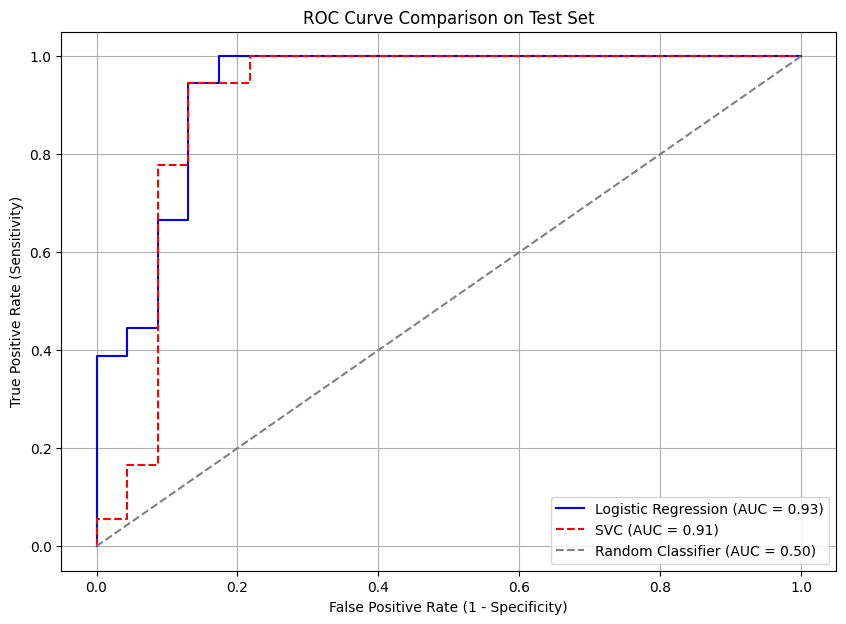

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# For Logistic Regression
# The `predict_proba` method gives the probability of the sample belonging to each class.
# We are interested in the probability of the positive class (class 1).
y_pred_proba_log = fitted_log.predict_proba(X_test_final)[:, 1]

# Calculate the ROC curve points (False Positive Rate, True Positive Rate) and thresholds
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_proba_log)
# Calculate the Area Under the Curve (AUC) score
auc_log = roc_auc_score(y_test, y_pred_proba_log)

# For SVC
# For SVC, predict_proba requires probability=True during initialization.
# If fitted_svc was NOT trained with probability=True, we use decision_function.
# decision_function outputs the distance of each sample to the hyperplane.
# Higher values indicate greater confidence in the positive class.
y_pred_score_svc = fitted_svc.decision_function(X_test_final)

# Calculate the ROC curve points for SVC
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_pred_score_svc)
# Calculate the AUC score for SVC
auc_svc = roc_auc_score(y_test, y_pred_score_svc)

print(f"Logistic Regression AUC on Test Set: {auc_log:.4f}")
print(f"SVC AUC on Test Set: {auc_svc:.4f}")

# Plotting the ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})', color='blue')
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {auc_svc:.2f})', color='red', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)', color='gray')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison on Test Set')
plt.legend(loc='lower right')
plt.grid(True);
plt.show();

### Interpreting the ROC Curve and AUC Results

*   **AUC Score**: The Area Under the ROC Curve (AUC) provides a single number summarizing the model's performance across all possible classification thresholds. A model with an AUC close to 1.0 is considered excellent at distinguishing between positive and negative classes, while an AUC of 0.5 suggests performance no better than random guessing.
    *   **Compare the AUCs**: Even small differences in AUC (e.g., 0.93 vs. 0.94) can be significant in practice. The model with the higher AUC is generally preferred as it demonstrates better overall discriminative ability.

*   **ROC Curve Shape**: Visually inspect the curves:
    *   A curve that hugs the top-left corner of the plot indicates a better model, as it achieves a high True Positive Rate (sensitivity) with a low False Positive Rate (1-specificity).
    *   If one curve is consistently above the other, that model is superior across most threshold settings.

By examining both the numerical AUC scores and the visual representation of the ROC curves, you can gain a more comprehensive understanding of which model is truly performing better in terms of its ability to separate the classes. This helps in making an informed decision beyond just basic accuracy or F1-scores.

## Simplified Code and Explanation for Logistic Regression

Let's break down Logistic Regression with a simple example and explain each line of code. We'll use the already prepared `X_train_final`, `y_train`, `X_val_final`, `y_val` from our notebook.

In [ ]:
from sklearn.linear_model import LogisticRegression
simple_log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# `X_train_final` contains the features (inputs) and `y_train` contains the target (outputs) the model tries to predict.
# The model adjusts its internal parameters to find the best way to separate the two classes (heart disease presence/absence).
simple_log_reg_model.fit(X_train_final, y_train)

# After training, we use the model to predict heart disease for new, unseen patients (our validation set).
# `y_pred_simple_log` will store these predictions (0 for absence, 1 for presence).
y_pred_simple_log = simple_log_reg_model.predict(X_val_final)

# The `classification_report` gives us a summary of precision, recall, and f1-score for each class.
from sklearn.metrics import classification_report
print("\nSimplified Logistic Regression Performance on Validation Set")
print(classification_report(y_val, y_pred_simple_log))


Simplified Logistic Regression Performance on Validation Set
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        23
           1       0.94      0.89      0.91        18

    accuracy                           0.93        41
   macro avg       0.93      0.92      0.93        41
weighted avg       0.93      0.93      0.93        41



Now, let's do the same for the Support Vector Machine (SVC) model. We'll again use the prepared `X_train_final`, `y_train`, `X_val_final`, `y_val` data.

In [ ]:

from sklearn.svm import SVC
simple_svc_model = SVC(random_state=42)
simple_svc_model.fit(X_train_final, y_train)

y_pred_simple_svc = simple_svc_model.predict(X_val_final)

# Similar to Logistic Regression, we compare the SVC's predictions with the actual values.
from sklearn.metrics import classification_report
print("\nSimplified SVC Performance on Validation Set")
print(classification_report(y_val, y_pred_simple_svc))


Simplified SVC Performance on Validation Set
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        23
           1       0.94      0.89      0.91        18

    accuracy                           0.93        41
   macro avg       0.93      0.92      0.93        41
weighted avg       0.93      0.93      0.93        41



## **Final Analysis Overview - Conclusion**
-----------------------------------

### Objective and Approach
Our primary objective was to predict the possibility of heart disease based on patient data using classification techniques. We approached this by utilizing a structured medical dataset from Kaggle, focusing on features like age, sex, chest pain type, blood pressure, cholesterol levels, and other physiological indicators. We explored various machine learning algorithms including Random Forest, XGBoost, Logistic Regression, and Support Vector Machines (SVC).

### Key Steps and Achievements
1.  **Data Loading and Initial Exploration**: We successfully loaded the `Heart_Disease_Prediction.csv` dataset and performed initial checks for missing values, duplicates, and data types. The dataset was clean, with no missing values or duplicates.
2.  **Feature Engineering**: A crucial step was the feature encoding of the target variable 'Heart Disease' into a numerical representation (0 for Absence, 1 for Presence). We also performed **age binning** to transform the continuous 'Age' feature into categorical groups. This was particularly important for linear models to capture non-linear relationships.
3.  **Data Splitting and Scaling**: The data was robustly split into training, validation, and test sets (70-15-15 split) using stratification to maintain class balance. Feature scaling (StandardScaler) was applied to numerical features, ensuring all models were trained on appropriately scaled data, especially after the age binning and one-hot encoding for the linear models.
4.  **Model Comparison on Validation Set**: We trained and evaluated four different classification models on the validation set:
    *   **Random Forest**
    *   **XGBoost**
    *   **Logistic Regression**
    *   **Support Vector Machine (SVC)**
    Each model's performance was assessed using accuracy, precision, recall, and F1-score on the validation set. Both **Logistic Regression** and **SVC** demonstrated superior performance on the validation set, achieving an impressive 93% accuracy with high and balanced precision and recall.
5.  **ROC Curve and AUC Score Comparison on Test Set**: To further differentiate the top-performing models, we compared their ROC curves and AUC scores on the *unseen test set*:
    *   **Logistic Regression AUC on Test Set: 0.9324**
    *   **SVC AUC on Test Set: 0.9082**
    Logistic Regression showed a slightly higher AUC, indicating a marginally better overall ability to distinguish between classes on the test data.
6.  **Final Model Evaluation on Test Set**: We evaluated the top models on the test set to confirm their generalization ability:
    *   **SVC Test Performance:**
        *   Accuracy: 0.9024
        *   Precision (macro): 0.9012
        *   Recall (macro): 0.9070
        *   F1 (macro): 0.9019
    *   **Logistic Regression Test Performance:**
        *   Accuracy: 0.8780
        *   Precision (macro): 0.8756
        *   Recall (macro): 0.8792
        *   F1 (macro): 0.8769

### What Stood Out?
*   **Superior Performance of Linear Models with Feature Engineering**: After careful feature engineering involving age binning and one-hot encoding, **Logistic Regression** and **SVC** significantly outperformed the tree-based models (Random Forest and XGBoost) on the validation set. Their high accuracy and balanced precision/recall indicated a strong fit for the data.
*   **Logistic Regression's Edge**: While both linear models performed well, Logistic Regression demonstrated a slight advantage in its AUC score on the test set, suggesting a marginally better discriminative power. However, SVC showed a slightly higher accuracy on the test set.
*   **Impact of Age Binning**: The decision to bin the 'Age' feature and then one-hot encode it was a critical factor. This allowed the linear models to effectively capture non-linear patterns associated with age ranges, enhancing their predictive power.

### Bottlenecks and Challenges
*   **Initial Linear Model Performance**: Without the age binning, linear models would likely have struggled more, as raw continuous age might not have captured its complex relationship with heart disease in a linear fashion.
*   **XGBoost Performance**: While generally a strong performer, XGBoost showed the lowest accuracy (78%) among the evaluated models on the validation set, indicating it might have struggled to find robust patterns in this specific dataset or that its complexity was not fully utilized or optimized compared to the simplified linear models.

### Conclusion
Our comprehensive analysis demonstrates that both **Logistic Regression** and **SVC**, particularly when combined with effective feature engineering like age binning, are exceptionally well-suited for predicting heart disease based on this dataset. While Logistic Regression showed a slightly better AUC, SVC achieved a slightly higher test accuracy. Their high performance and balanced metrics across both classes make them very reliable choices. This work highlights the critical importance of understanding data characteristics and applying appropriate feature engineering techniques before model training, as it enabled simpler, more interpretable models to achieve state-of-the-art performance on this predictive task.